libraries


In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, train_test_split

from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

 Load dataset

In [64]:
url="https://raw.githubusercontent.com/mibur1/psy111/main/book/statistics/4_Moderated_Reg/data/StressLevelDataset.csv"

df_raw=pd.read_csv(url)
df=df_raw.copy()

df.head()

,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,...,basic_needs,academic_performance,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying,stress_level
0,14,20,0,11,2,1,2,4,2,3,...,2,3,2,3,3,2,3,3,2,1
1,15,8,1,15,5,3,1,4,3,1,...,2,1,4,1,5,1,4,5,5,2
2,12,18,1,14,2,1,2,2,2,2,...,2,2,3,3,2,2,3,2,2,1
3,16,12,1,15,4,3,1,3,4,2,...,2,2,4,1,4,1,4,4,5,2
4,16,28,0,7,2,3,5,1,3,2,...,3,4,3,1,2,1,5,0,5,1


Data checking

In [68]:
print("First 5 rows:")
display(df.head())

print("\nLast 5 rows:")
display(df.tail())

print("\nDataset shape:")
print(df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nDataset information:")
df.info()

print("\nDescriptive statistics:")
display(df.describe())

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())



First 5 rows:


,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,...,basic_needs,academic_performance,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying,stress_level
0,14,20,0,11,2,1,2,4,2,3,...,2,3,2,3,3,2,3,3,2,1
1,15,8,1,15,5,3,1,4,3,1,...,2,1,4,1,5,1,4,5,5,2
2,12,18,1,14,2,1,2,2,2,2,...,2,2,3,3,2,2,3,2,2,1
3,16,12,1,15,4,3,1,3,4,2,...,2,2,4,1,4,1,4,4,5,2
4,16,28,0,7,2,3,5,1,3,2,...,3,4,3,1,2,1,5,0,5,1



Last 5 rows:


,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,...,basic_needs,academic_performance,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying,stress_level
1095,11,17,0,14,3,1,3,2,2,2,...,3,2,2,2,3,3,2,3,3,1
1096,9,12,0,8,0,3,0,0,0,1,...,4,0,1,1,1,1,3,4,3,2
1097,4,26,0,3,1,2,5,2,2,3,...,4,5,1,4,1,3,1,2,1,0
1098,21,0,1,19,5,3,1,4,3,1,...,1,2,5,1,4,1,4,4,4,2
1099,18,6,1,15,3,3,0,3,3,0,...,3,3,4,3,3,1,5,1,4,2



Dataset shape:
(1100, 21)

Column names:
['anxiety_level', 'self_esteem', 'mental_health_history', 'depression', 'headache', 'blood_pressure', 'sleep_quality', 'breathing_problem', 'noise_level', 'living_conditions', 'safety', 'basic_needs', 'academic_performance', 'study_load', 'teacher_student_relationship', 'future_career_concerns', 'social_support', 'peer_pressure', 'extracurricular_activities', 'bullying', 'stress_level']

Data types:
anxiety_level                   int64
self_esteem                     int64
mental_health_history           int64
depression                      int64
headache                        int64
blood_pressure                  int64
sleep_quality                   int64
breathing_problem               int64
noise_level                     int64
living_conditions               int64
safety                          int64
basic_needs                     int64
academic_performance            int64
study_load                      int64
teacher_student_relatio

,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,...,basic_needs,academic_performance,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying,stress_level
count,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,...,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000
mean,11.063636,17.777273,0.492727,12.555455,2.508182,2.181818,2.660000,2.753636,2.649091,2.518182,...,2.772727,2.772727,2.621818,2.648182,2.649091,1.881818,2.734545,2.767273,2.617273,0.996364
std,6.117558,8.944599,0.500175,7.727008,1.409356,0.833575,1.548383,1.400713,1.328127,1.119208,...,1.433761,1.414594,1.315781,1.384579,1.529375,1.047826,1.425265,1.417562,1.530958,0.821673
min,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,6.000000,11.000000,0.000000,6.000000,1.000000,1.000000,1.000000,2.000000,2.000000,2.000000,...,2.000000,2.000000,2.000000,2.000000,1.000000,1.000000,2.000000,2.000000,1.000000,0.000000
50%,11.000000,19.000000,0.000000,12.000000,3.000000,2.000000,2.500000,3.000000,3.000000,2.000000,...,3.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.500000,3.000000,1.000000
75%,16.000000,26.000000,1.000000,19.000000,3.000000,3.000000,4.000000,4.000000,3.000000,3.000000,...,4.000000,4.000000,3.000000,4.000000,4.000000,3.000000,4.000000,4.000000,4.000000,2.000000
max,21.000000,30.000000,1.000000,27.000000,5.000000,3.000000,5.000000,5.000000,5.000000,5.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,3.000000,5.000000,5.000000,5.000000,2.000000



Missing values:
anxiety_level                   0
self_esteem                     0
mental_health_history           0
depression                      0
headache                        0
blood_pressure                  0
sleep_quality                   0
breathing_problem               0
noise_level                     0
living_conditions               0
safety                          0
basic_needs                     0
academic_performance            0
study_load                      0
teacher_student_relationship    0
future_career_concerns          0
social_support                  0
peer_pressure                   0
extracurricular_activities      0
bullying                        0
stress_level                    0
dtype: int64

Duplicate rows:
0


Data Cleaning

In [69]:
# Dropped columns that are not required for the analysis
df = df.drop(columns=["blood_pressure", "headache"])

# Filled missing numeric values with the median
numeric_columns = df.select_dtypes(include=np.number).columns
df[numeric_columns] = df[numeric_columns].fillna(
    df[numeric_columns].median()
)

# Removed duplicate rows
df = df.drop_duplicates()

# Reset index
df = df.reset_index(drop=True)

# Created mental health score
df["mental_health_score"] = (
    df["depression"] + df["anxiety_level"]
) / 2

# Created binary target for low academic performance
df["low_performance"] = (
    df["academic_performance"] <= 2
).astype(int)

# Removed the original academic performance column
df = df.drop(columns=["academic_performance"])

print("Final dataset shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

display(df.head())

Final dataset shape: (1100, 20)

Missing values:
anxiety_level                   0
self_esteem                     0
mental_health_history           0
depression                      0
sleep_quality                   0
breathing_problem               0
noise_level                     0
living_conditions               0
safety                          0
basic_needs                     0
study_load                      0
teacher_student_relationship    0
future_career_concerns          0
social_support                  0
peer_pressure                   0
extracurricular_activities      0
bullying                        0
stress_level                    0
mental_health_score             0
low_performance                 0
dtype: int64

Duplicate rows:
0


,anxiety_level,self_esteem,mental_health_history,depression,sleep_quality,breathing_problem,noise_level,living_conditions,safety,basic_needs,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying,stress_level,mental_health_score,low_performance
0,14,20,0,11,2,4,2,3,3,2,2,3,3,2,3,3,2,1,12.5,0
1,15,8,1,15,1,4,3,1,2,2,4,1,5,1,4,5,5,2,15.0,1
2,12,18,1,14,2,2,2,2,3,2,3,3,2,2,3,2,2,1,13.0,1
3,16,12,1,15,1,3,4,2,2,2,4,1,4,1,4,4,5,2,15.5,1
4,16,28,0,7,5,1,3,2,4,3,3,1,2,1,5,0,5,1,11.5,0


Data Exploration

Graph 1 — Academic Performance Distribution

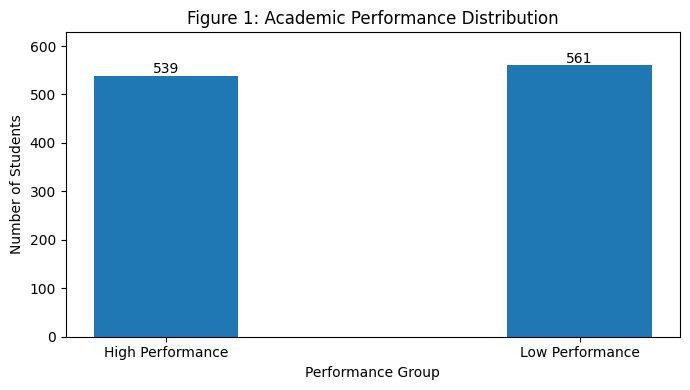

In [72]:
counts=df["low_performance"].value_counts().sort_index()

plt.figure(figsize=(7,4))

values=[counts[0],counts[1]]

plt.bar(
    ["High Performance","Low Performance"],
    values,
    width=0.35
)

plt.title("Figure 1: Academic Performance Distribution")
plt.xlabel("Performance Group")
plt.ylabel("Number of Students")
plt.ylim(0,max(values)*1.12)

for i,value in enumerate(values):
    plt.text(
        i,
        value+5,
        str(value),
        ha="center"
    )

plt.tight_layout()

plt.show()


Graph 2- Average Stress Level by Performance Group

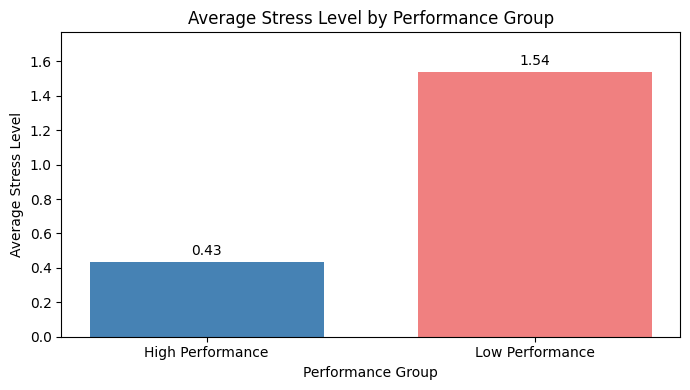

In [36]:
stress=df.groupby(
    "low_performance"
)["stress_level"].mean()

plt.figure(figsize=(7,4))

plt.bar(
    [0,0.35],
    [stress[0],stress[1]],
    width=0.25,
    color=["steelblue","lightcoral"]
)

plt.xticks(
    [0,0.35],
    ["High Performance","Low Performance"]
)

plt.title("Average Stress Level by Performance Group")

plt.xlabel("Performance Group")

plt.ylabel("Average Stress Level")

plt.ylim(0,max(stress)*1.15)

plt.text(
    0,
    stress[0]+0.04,
    f"{stress[0]:.2f}",
    ha="center"
)

plt.text(
    0.35,
    stress[1]+0.04,
    f"{stress[1]:.2f}",
    ha="center"
)

plt.tight_layout()

plt.savefig("graph2_stress.png")

plt.show()

Graph 3-Average Sleep Quality by Performance Group

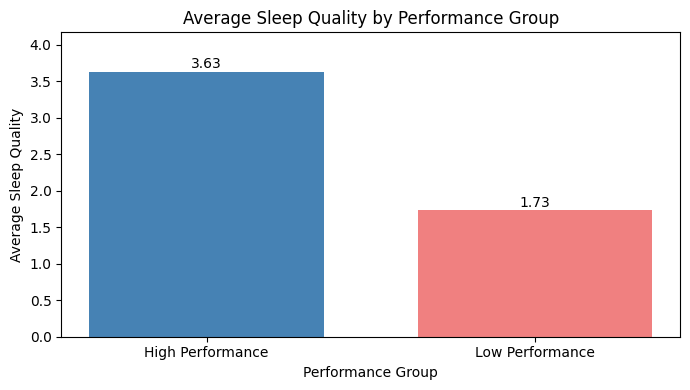

In [37]:
sleep=df.groupby(
    "low_performance"
)["sleep_quality"].mean()

plt.figure(figsize=(7,4))

plt.bar(
    [0,0.35],
    [sleep[0],sleep[1]],
    width=0.25,
    color=["steelblue","lightcoral"]
)

plt.xticks(
    [0,0.35],
    ["High Performance","Low Performance"]
)

plt.title("Average Sleep Quality by Performance Group")
plt.xlabel("Performance Group")
plt.ylabel("Average Sleep Quality")

plt.ylim(0,max(sleep)*1.15)

plt.text(
    0,
    sleep[0]+0.05,
    f"{sleep[0]:.2f}",
    ha="center"
)

plt.text(
    0.35,
    sleep[1]+0.05,
    f"{sleep[1]:.2f}",
    ha="center"
)

plt.tight_layout()
plt.show()



Graph 4-Average Mental Health Score by Performance Group

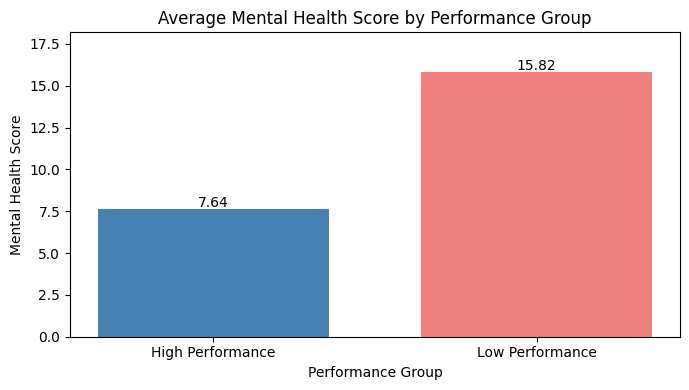

In [38]:
mental_health=df.groupby(
    "low_performance"
)["mental_health_score"].mean()

plt.figure(figsize=(7,4))

plt.bar(
    [0,0.35],
    [mental_health[0],mental_health[1]],
    width=0.25,
    color=["steelblue","lightcoral"]
)

plt.xticks(
    [0,0.35],
    ["High Performance","Low Performance"]
)

plt.title("Average Mental Health Score by Performance Group")
plt.xlabel("Performance Group")
plt.ylabel("Mental Health Score")

plt.ylim(0,max(mental_health)*1.15)

plt.text(
    0,
    mental_health[0]+0.1,
    f"{mental_health[0]:.2f}",
    ha="center"
)

plt.text(
    0.35,
    mental_health[1]+0.1,
    f"{mental_health[1]:.2f}",
    ha="center"
)

plt.tight_layout()
plt.savefig("graph4_mental_health.png")
plt.show()


Feature Selection


In [76]:
features = [
    "stress_level",
    "mental_health_score",
    "sleep_quality",
    "social_support",
    "self_esteem"
]

X = df[features]
y = df["low_performance"]

print("Features:")
print(features)

print("\nTarget distribution:")
print(y.value_counts())

print("\nX shape:", X.shape)
print("y shape:", y.shape)

Features:
['stress_level', 'mental_health_score', 'sleep_quality', 'social_support', 'self_esteem']

Target distribution:
low_performance
1    561
0    539
Name: count, dtype: int64

X shape: (1100, 5)
y shape: (1100,)


Train-Test Split

In [77]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (825, 5)
Testing set: (275, 5)


KNN and LOgistic Regression Pipelines

In [78]:
knn_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=7))
])

logistic_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("logistic", LogisticRegression(max_iter=1000))
])

print("KNN and Logistic Regression pipelines created.")

KNN and Logistic Regression pipelines created.


Cross Validation Score

In [79]:
knn_cv_scores = cross_val_score(
    knn_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring="balanced_accuracy"
)

logistic_cv_scores = cross_val_score(
    logistic_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring="balanced_accuracy"
)

print("KNN balanced accuracy:")
print(knn_cv_scores)
print("KNN mean:", knn_cv_scores.mean())

print("\nLogistic Regression balanced accuracy:")
print(logistic_cv_scores)
print("Logistic Regression mean:", logistic_cv_scores.mean())

KNN balanced accuracy:
[0.76212522 0.74955908 0.75749559 0.71957672 0.75919118]
KNN mean: 0.7495895580454404

Logistic Regression balanced accuracy:
[0.8053351  0.79872134 0.77116402 0.73236332 0.77279412]
Logistic Regression mean: 0.7760755783795


Train Models,Predictions and Baseline Model

In [80]:
knn_pipeline.fit(X_train, y_train)
logistic_pipeline.fit(X_train, y_train)

knn_predictions = knn_pipeline.predict(X_test)
logistic_predictions = logistic_pipeline.predict(X_test)

baseline = DummyClassifier(
    strategy="most_frequent",
    random_state=RANDOM_STATE
)

baseline.fit(X_train, y_train)
baseline_predictions = baseline.predict(X_test)

print("Models trained successfully.")

Models trained successfully.


Model performance

In [81]:
results = pd.DataFrame({
    "Model": [
        "Baseline",
        "Logistic Regression",
        "KNN"
    ],
    "Accuracy": [
        accuracy_score(y_test, baseline_predictions),
        accuracy_score(y_test, logistic_predictions),
        accuracy_score(y_test, knn_predictions)
    ],
    "Precision": [
        precision_score(y_test, baseline_predictions),
        precision_score(y_test, logistic_predictions),
        precision_score(y_test, knn_predictions)
    ],
    "Recall": [
        recall_score(y_test, baseline_predictions),
        recall_score(y_test, logistic_predictions),
        recall_score(y_test, knn_predictions)
    ],
    "F1 Score": [
        f1_score(y_test, baseline_predictions),
        f1_score(y_test, logistic_predictions),
        f1_score(y_test, knn_predictions)
    ]
})

display(results)

,Model,Accuracy,Precision,Recall,F1 Score
0,Baseline,0.509091,0.509091,1.000000,0.674699
1,Logistic Regression,0.763636,0.758621,0.785714,0.771930
2,KNN,0.756364,0.738562,0.807143,0.771331


Classification Report

In [90]:
print("Baseline Classification Report")
print(
    classification_report(
        y_test,
        baseline_predictions,
        digits=3
    )
)

print("\nLogistic Regression Classification Report")
print(
    classification_report(
        y_test,
        logistic_predictions,
        digits=3
    )
)

print("\nKNN Classification Report")
print(
    classification_report(
        y_test,
        knn_predictions,
        digits=3
    )
)

Baseline Classification Report
              precision    recall  f1-score   support

           0      0.000     0.000     0.000       135
           1      0.509     1.000     0.675       140

    accuracy                          0.509       275
   macro avg      0.255     0.500     0.337       275
weighted avg      0.259     0.509     0.343       275


Logistic Regression Classification Report
              precision    recall  f1-score   support

           0      0.769     0.741     0.755       135
           1      0.759     0.786     0.772       140

    accuracy                          0.764       275
   macro avg      0.764     0.763     0.763       275
weighted avg      0.764     0.764     0.763       275


KNN Classification Report
              precision    recall  f1-score   support

           0      0.779     0.704     0.739       135
           1      0.739     0.807     0.771       140

    accuracy                          0.756       275
   macro avg      0.759    

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Confusion matrices

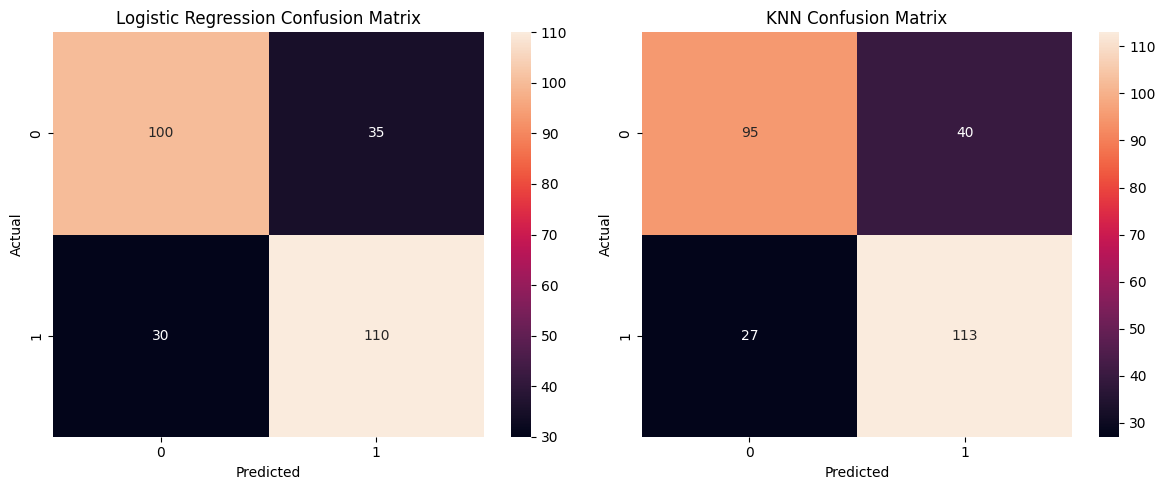

In [91]:
cm_logistic = confusion_matrix(
    y_test,
    logistic_predictions
)

cm_knn = confusion_matrix(
    y_test,
    knn_predictions
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(
    cm_logistic,
    annot=True,
    fmt="d",
    ax=axes[0]
)

axes[0].set_title("Logistic Regression Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(
    cm_knn,
    annot=True,
    fmt="d",
    ax=axes[1]
)

axes[1].set_title("KNN Confusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

Model Comparison

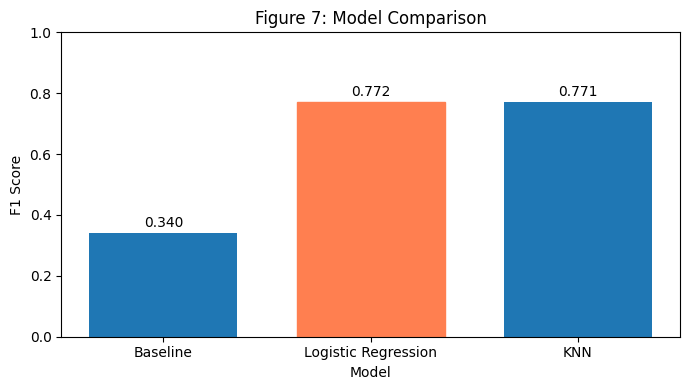

In [93]:
models = [
    "Baseline",
    "Logistic Regression",
    "KNN"
]

scores = [
    0.340,
    0.772,
    0.771
]

plt.figure(figsize=(7, 4))

bars = plt.bar(
    [0, 0.35, 0.70],
    scores,
    width=0.25
)


bars[1].set_color("coral")

plt.xticks(
    [0, 0.35, 0.70],
    models
)

plt.title("Figure 7: Model Comparison")
plt.xlabel("Model")
plt.ylabel("F1 Score")
plt.ylim(0, 1)

# Show 3 digits on top of each bar
for x, score in zip([0, 0.35, 0.70], scores):
    plt.text(
        x,
        score + 0.02,
        f"{score:.3f}",
        ha="center"
    )

plt.tight_layout()

plt.show()

Conclusion

This highlights that students’ stress,mental health,sleep quality,social support and self-esteem are useful factors for understanding academic performance. Logistic Regression and KNN both performed well compared with the baseline with Logistic Regression showing a slightly better performance than KNN.Overall the findings suggest that students’ wellbeing and lifestyle factors can provide valuable insights into academic performance.